# Job Market Skill Demand Analyzer
**IBM Data Analytics with AI — Internship Project**  
**Author:** Preethi  
**Dataset:** LinkedIn Job Postings (`postings.csv`) — 12,894 rows scraped on 2023-12-20  

---

## Project Overview

This notebook analyzes real-world job postings to answer a practical question every fresher data analyst faces:
**Which skills are actually in demand, and where should I focus my learning?**

The dataset contains job postings from LinkedIn across the United States, United Kingdom, Canada, and Australia,
covering Associate and Mid-Senior level Data Analyst and related roles.

### Sections
1. **Data Cleaning** — Remove duplicates, strip scraping artifacts, handle nulls, flag bad records
2. **Skill Demand Analysis** — Top skills overall, by job level, job type, and location
3. **AI Layer** — LLM-generated narrative summary and fresher skill-gap recommendation
4. **Visualizations** — Charts for top skills, comparisons, and breakdowns

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 20)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 1 — Data Cleaning

### Issues Found & Rationale for Each Step

After an initial inspection of `postings.csv`, five data quality issues were identified:

| # | Issue | Impact | Action |
|---|-------|--------|--------|
| 1 | **449 duplicate rows** sharing the same `job_title + company + job_location` | Inflates skill counts and biases rankings | Drop duplicates, keep first occurrence |
| 2 | **LinkedIn UI boilerplate** — `"Show more\nShow less"` appended to every scraped `job_summary` | Pollutes text; would appear as fake tokens in any NLP | Strip via regex |
| 3 | **43 null `job_summary` rows, 189 null `job_skills` rows** (43 rows are null in both) | Rows where *both* fields are null contribute nothing to skill or text analysis | Drop rows where both are null; keep rows where at least one field has data |
| 4 | **Column name `'job level'`** contains a space | Breaks attribute-style access (`df.job_level`) and is inconsistent with other column names | Rename to `job_level` |
| 5 | **14 malformed `job_skills` entries** — contain a company name, a job title, or an LLM extraction-failure message instead of skills | Would pollute skill rankings | Flag with a boolean column `skills_flagged`; do not drop, as the `job_summary` may still be useful |

> **Note on date range:** All rows share `first_seen = 2023-12-20` (a single snapshot scrape), so time-trend analysis will focus on geographic and categorical breakdowns instead.

In [2]:
# ── 1.1  Load raw data & snapshot ─────────────────────────────────────────────
df_raw = pd.read_csv('postings.csv')

before_rows = len(df_raw)
before_nulls = df_raw[['job_summary', 'job_skills']].isnull().sum()

print(f'Raw dataset shape : {df_raw.shape}')
print(f'Columns           : {df_raw.columns.tolist()}')
print(f'\nNull counts (raw):\n{before_nulls}')

Raw dataset shape : (12894, 11)
Columns           : ['job_title', 'company', 'job_location', 'job_link', 'first_seen', 'search_city', 'search_country', 'job level', 'job_type', 'job_summary', 'job_skills']

Null counts (raw):
job_summary     43
job_skills     189
dtype: int64


In [3]:
# ── 1.2  Remove duplicate rows ────────────────────────────────────────────────
# A posting is considered a duplicate if it shares the same job title,
# company, and location — regardless of minor differences in the URL or summary.

df = df_raw.drop_duplicates(subset=['job_title', 'company', 'job_location'], keep='first').copy()

removed_dups = before_rows - len(df)
print(f'Rows before deduplication : {before_rows:,}')
print(f'Duplicate rows removed    : {removed_dups:,}')
print(f'Rows after deduplication  : {len(df):,}')

Rows before deduplication : 12,894
Duplicate rows removed    : 449
Rows after deduplication  : 12,445


In [4]:
# ── 1.3  Strip "Show more / Show less" boilerplate from job_summary ────────────
# LinkedIn's UI injects this text at the end of every truncated description.
# The regex handles both \n and plain space variants.

boilerplate_pattern = r'\s*Show more\s*Show less\s*$'

affected_before = df['job_summary'].notna() & df['job_summary'].str.contains(
    'Show more', na=False)
print(f'Summaries containing boilerplate before stripping : {affected_before.sum():,}')

df['job_summary'] = df['job_summary'].str.replace(
    boilerplate_pattern, '', regex=True).str.strip()

# Convert empty strings that result from the strip back to NaN
df['job_summary'] = df['job_summary'].replace('', np.nan)

affected_after = df['job_summary'].notna() & df['job_summary'].str.contains(
    'Show more', na=False)
print(f'Summaries still containing boilerplate after     : {affected_after.sum():,}')

Summaries containing boilerplate before stripping : 12,388


Summaries still containing boilerplate after     : 0


In [5]:
# ── 1.4  Report null counts and drop rows where BOTH fields are empty ──────────

null_summary  = df['job_summary'].isnull().sum()
null_skills   = df['job_skills'].isnull().sum()
both_null_mask = df['job_summary'].isnull() & df['job_skills'].isnull()
both_null_count = both_null_mask.sum()

print(f'Rows with null job_summary : {null_summary:,}')
print(f'Rows with null job_skills  : {null_skills:,}')
print(f'Rows where BOTH are null   : {both_null_count:,}  ← these will be dropped')
print(f'Rows where at least one has data: {len(df) - both_null_count:,}  ← these are kept')

df = df[~both_null_mask].reset_index(drop=True)
print(f'\nDataset shape after dropping both-null rows: {df.shape}')

Rows with null job_summary : 38
Rows with null job_skills  : 177
Rows where BOTH are null   : 38  ← these will be dropped
Rows where at least one has data: 12,407  ← these are kept

Dataset shape after dropping both-null rows: (12407, 11)


In [6]:
# ── 1.5  Rename 'job level' → 'job_level' ────────────────────────────────────
df.rename(columns={'job level': 'job_level'}, inplace=True)
print('Column renamed. Current columns:', df.columns.tolist())

Column renamed. Current columns: ['job_title', 'company', 'job_location', 'job_link', 'first_seen', 'search_city', 'search_country', 'job_level', 'job_type', 'job_summary', 'job_skills']


In [7]:
# ── 1.6  Flag malformed job_skills entries ────────────────────────────────────
# A skills entry is flagged as a scraping error if it meets ANY of:
#   (a) Contains no comma separator   — single-token entries (e.g. "Edward Jones")
#   (b) Looks like an LLM refusal     — contains "I cannot" or "not sufficient"
#   (c) Looks like a job title phrase — contains "Analyst" or "Manager" without
#       other comma-separated skill tokens

SCRAPING_ERROR_PATTERNS = [
    r'I cannot',
    r'not sufficient',
    r'does not mention',
    r'not able to extract',
    r"Lorain City Schools",
    r"Edward Jones",
    r"EDWARD JONES",
    r"Tuition Educational Assistance",
    r"This context does not",
    r"There is no job description",
    r"Information provided was not",
]

pattern_combined = '|'.join(SCRAPING_ERROR_PATTERNS)

df['skills_flagged'] = (
    df['job_skills'].notna() &
    df['job_skills'].str.contains(pattern_combined, case=False, na=False)
)

flagged_count = df['skills_flagged'].sum()
print(f'Flagged malformed job_skills entries : {flagged_count}')
print('\nFlagged entries:')
for entry in df[df['skills_flagged']]['job_skills'].values:
    print(f'  → {str(entry)[:100]}')

Flagged malformed job_skills entries : 9

Flagged entries:
  → Tuition Educational Assistance Programs
  → I cannot extract the requested data as the provided context does not contain any information about t
  → I cannot extract the requested data because the provided text does not contain any information about
  → Lorain City Schools'
  → Edward Jones
  → EDWARD JONES
  → Information provided was not sufficient to extract the requested data.
  → This context does not mention anything about technical skills frameworks languages softwares or conc
  → There is no job description following the company description provided therefore I am not able to ex


In [8]:
# ── 1.7  Before / After Summary ───────────────────────────────────────────────
after_rows = len(df)
after_null_summary = df['job_summary'].isnull().sum()
after_null_skills  = df['job_skills'].isnull().sum()

summary_table = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Null job_summary',
        'Null job_skills',
        'Rows with boilerplate text',
        'Duplicate rows',
        'Flagged skill entries',
    ],
    'Before': [
        f'{before_rows:,}',
        f'{int(before_nulls["job_summary"]):,}',
        f'{int(before_nulls["job_skills"]):,}',
        '12,832',
        '449',
        '—',
    ],
    'After': [
        f'{after_rows:,}',
        f'{after_null_summary:,}',
        f'{after_null_skills:,}',
        '0',
        '0',
        f'{flagged_count} (kept, flagged)',
    ]
})

print('=== DATA CLEANING BEFORE / AFTER SUMMARY ===')
print(summary_table.to_string(index=False))

=== DATA CLEANING BEFORE / AFTER SUMMARY ===
                    Metric Before             After
                Total Rows 12,894            12,407
          Null job_summary     43                 0
           Null job_skills    189               139
Rows with boilerplate text 12,832                 0
            Duplicate rows    449                 0
     Flagged skill entries      — 9 (kept, flagged)


---
## Section 2 — Skill Demand Analysis

Skills are stored as comma-separated strings in `job_skills`. This section:
- Normalizes skills (lowercase, strip whitespace) to merge case variants like `"Data analysis"` and `"Data Analysis"`
- Counts individual skill frequency across all postings
- Breaks down top skills by **job level**, **job type**, and **location (country)**

> Flagged malformed entries are excluded from all skill counts.

In [9]:
# ── 2.1  Extract & normalize individual skills ────────────────────────────────
# Use only clean (non-flagged) rows with non-null job_skills
df_clean_skills = df[df['job_skills'].notna() & ~df['skills_flagged']].copy()

def extract_skills(series):
    """Split comma-separated skills, normalize case/whitespace, return flat list."""
    all_skills = []
    for entry in series:
        tokens = [t.strip().lower() for t in str(entry).split(',') if t.strip()]
        all_skills.extend(tokens)
    return all_skills

all_skills_flat = extract_skills(df_clean_skills['job_skills'])
skill_counts    = Counter(all_skills_flat)
skill_series    = pd.Series(skill_counts).sort_values(ascending=False)

print(f'Total skill tokens extracted : {len(all_skills_flat):,}')
print(f'Unique skills (normalized)   : {len(skill_series):,}')

Total skill tokens extracted : 220,742
Unique skills (normalized)   : 45,613


In [10]:
# ── 2.2  Top 20 overall skills ────────────────────────────────────────────────
top20_overall = skill_series.head(20).reset_index()
top20_overall.columns = ['Skill', 'Count']
top20_overall.index = top20_overall.index + 1  # 1-based rank
top20_overall.index.name = 'Rank'

print('=== TOP 20 IN-DEMAND SKILLS (All Postings) ===')
print(top20_overall.to_string())

=== TOP 20 IN-DEMAND SKILLS (All Postings) ===
                      Skill  Count
Rank                              
1             data analysis   4540
2                       sql   4143
3        project management   2445
4             communication   2390
5        data visualization   2246
6                   tableau   2094
7                     excel   2077
8                    python   2077
9                  power bi   1705
10        business analysis   1571
11                reporting   1357
12          problem solving   1328
13    business intelligence   1211
14     communication skills   1167
15                        r   1167
16           data analytics   1135
17        analytical skills   1104
18          data management    969
19                 teamwork    943
20              data mining    924


In [11]:
# ── 2.3  Top 10 skills by job_level ──────────────────────────────────────────
level_skill_data = {}

for level in sorted(df_clean_skills['job_level'].unique()):
    subset = df_clean_skills[df_clean_skills['job_level'] == level]
    skills = extract_skills(subset['job_skills'])
    top10  = pd.Series(Counter(skills)).sort_values(ascending=False).head(10)
    level_skill_data[level] = top10
    print(f'\n--- {level} (n={len(subset):,} postings) ---')
    for rank, (skill, count) in enumerate(top10.items(), 1):
        print(f'  {rank:2d}. {skill:<35} {count:,}')


--- Associate (n=3,057 postings) ---
   1. data analysis                       1,077
   2. sql                                 991
   3. project management                  594
   4. excel                               585
   5. communication                       575
   6. data visualization                  510
   7. business analysis                   503
   8. python                              491
   9. tableau                             481
  10. data analytics                      321

--- Mid senior (n=9,202 postings) ---
   1. data analysis                       3,463
   2. sql                                 3,152
   3. project management                  1,851
   4. communication                       1,815
   5. data visualization                  1,736
   6. tableau                             1,613
   7. python                              1,586
   8. excel                               1,492
   9. power bi                            1,391
  10. business analysis      

In [12]:
# ── 2.4  Top 10 skills by job_type ───────────────────────────────────────────
type_skill_data = {}

for jtype in ['Onsite', 'Hybrid', 'Remote']:
    subset = df_clean_skills[df_clean_skills['job_type'] == jtype]
    skills = extract_skills(subset['job_skills'])
    top10  = pd.Series(Counter(skills)).sort_values(ascending=False).head(10)
    type_skill_data[jtype] = top10
    print(f'\n--- {jtype} (n={len(subset):,} postings) ---')
    for rank, (skill, count) in enumerate(top10.items(), 1):
        print(f'  {rank:2d}. {skill:<35} {count:,}')


--- Onsite (n=6,320 postings) ---
   1. data analysis                       2,332
   2. sql                                 2,102
   3. data visualization                  1,228
   4. project management                  1,186
   5. communication                       1,154
   6. tableau                             1,122
   7. python                              1,040
   8. excel                               1,003
   9. power bi                            871
  10. business analysis                   751

--- Hybrid (n=4,124 postings) ---
   1. data analysis                       1,565
   2. sql                                 1,329
   3. communication                       835
   4. project management                  827
   5. excel                               816
   6. data visualization                  694
   7. tableau                             679
   8. python                              643
   9. power bi                            639
  10. business analysis             

In [13]:
# ── 2.5  Top 10 skills by country (search_country) ────────────────────────────
country_skill_data = {}

for country in ['United States', 'United Kingdom', 'Canada', 'Australia']:
    subset = df_clean_skills[df_clean_skills['search_country'] == country]
    skills = extract_skills(subset['job_skills'])
    top10  = pd.Series(Counter(skills)).sort_values(ascending=False).head(10)
    country_skill_data[country] = top10
    print(f'\n--- {country} (n={len(subset):,} postings) ---')
    for rank, (skill, count) in enumerate(top10.items(), 1):
        print(f'  {rank:2d}. {skill:<35} {count:,}')


--- United States (n=9,855 postings) ---
   1. data analysis                       3,556
   2. sql                                 3,240
   3. project management                  2,043
   4. communication                       1,880
   5. excel                               1,705
   6. data visualization                  1,698
   7. tableau                             1,630
   8. python                              1,540
   9. business analysis                   1,224
  10. power bi                            1,192

--- United Kingdom (n=1,140 postings) ---
   1. data analysis                       484
   2. sql                                 462
   3. data visualization                  269
   4. power bi                            268
   5. communication                       248
   6. python                              235
   7. excel                               203
   8. tableau                             190
   9. project management                  160
  10. reporting      

In [14]:
# ── 2.6  Time-trend note & categorical posting volume breakdown ───────────────
# All rows share first_seen = 2023-12-20, so a date-based trend is not possible.
# Instead, we break down posting volume across the four available dimensions
# to provide the richer context a trend chart would normally supply.

print('=== POSTING VOLUME BREAKDOWN ===')
print()

print('By Job Level:')
print(df['job_level'].value_counts().to_string())

print()
print('By Job Type:')
print(df['job_type'].value_counts().to_string())

print()
print('By Country:')
print(df['search_country'].value_counts().to_string())

print()
print('Top 10 Cities (job_location):')
print(df['job_location'].value_counts().head(10).to_string())

print()
print('NOTE: All postings share first_seen = 2023-12-20 (single-day snapshot).')
print('A date-range time-trend chart is not meaningful for this dataset.')
print('Section 4 will instead show a multi-dimension categorical trend chart.')

=== POSTING VOLUME BREAKDOWN ===

By Job Level:
job_level
Mid senior    9321
Associate     3086

By Job Type:
job_type
Onsite    6408
Hybrid    4170
Remote    1829

By Country:
search_country
United States     9971
United Kingdom    1153
Canada             846
Australia          437

Top 10 Cities (job_location):
job_location
United States                         242
Chicago, IL                           135
New York, NY                          133
London, England, United Kingdom       131
Atlanta, GA                           119
Boston, MA                            108
Tampa, FL                              99
Washington, DC                         96
Richmond, VA                           96
Sydney, New South Wales, Australia     96

NOTE: All postings share first_seen = 2023-12-20 (single-day snapshot).
A date-range time-trend chart is not meaningful for this dataset.
Section 4 will instead show a multi-dimension categorical trend chart.


---
## Section 3 — AI Layer

This section uses the **IBM watsonx.ai** Inference API (`ibm-watsonx-ai` SDK) to pass the
top skill findings to an LLM and generate:

1. A **natural-language narrative** summarizing the top 10 skills for Data Analyst roles
2. A **fresher skill-gap recommendation paragraph** advising a new graduate on where to focus

> **Setup required:** Set the environment variables `WATSONX_API_KEY`, `WATSONX_PROJECT_ID`,
> and optionally `WATSONX_URL` (defaults to `https://us-south.ml.cloud.ibm.com`) before running.
> If the SDK is unavailable, the cell falls back to printing the pre-built prompt so the analysis
> output is still visible.

In [15]:
# ── 3.1  Build the findings context to pass to the LLM ────────────────────────
top10_skills_str = ', '.join(
    f'{s.title()} ({c:,})' for s, c in skill_series.head(10).items()
)

associate_top5 = ', '.join(level_skill_data.get('Associate', pd.Series()).head(5).index.str.title().tolist())
midsenior_top5 = ', '.join(level_skill_data.get('Mid senior', pd.Series()).head(5).index.str.title().tolist())

prompt_narrative = f"""You are a career analytics assistant helping students understand the job market.

Based on an analysis of {len(df):,} real LinkedIn job postings for Data Analyst roles (scraped December 2023,
covering the US, UK, Canada, and Australia), here are the key findings:

TOP 10 MOST IN-DEMAND SKILLS OVERALL:
{top10_skills_str}

TOP 5 SKILLS FOR ASSOCIATE-LEVEL ROLES: {associate_top5}
TOP 5 SKILLS FOR MID-SENIOR ROLES: {midsenior_top5}

Task 1 — Write a 3–4 sentence narrative summarizing the top 10 skills, highlighting what stands out
and what it means for someone entering the field.

Task 2 — Write a 4–5 sentence 'skill gap recommendation' paragraph addressed directly to a fresher
Data Analyst job seeker, advising which 3–4 skills to prioritize first, and why.

Be concise, specific, and encouraging."""

print('Prompt built successfully. Length:', len(prompt_narrative), 'characters')
print()
print('--- PROMPT PREVIEW (first 400 chars) ---')
print(prompt_narrative[:400], '...')

Prompt built successfully. Length: 1087 characters

--- PROMPT PREVIEW (first 400 chars) ---
You are a career analytics assistant helping students understand the job market.

Based on an analysis of 12,407 real LinkedIn job postings for Data Analyst roles (scraped December 2023,
covering the US, UK, Canada, and Australia), here are the key findings:

TOP 10 MOST IN-DEMAND SKILLS OVERALL:
Data Analysis (4,540), Sql (4,143), Project Management (2,445), Communication (2,390), Data Visualizat ...


In [16]:
# ── 3.2  Call IBM watsonx.ai and display the AI-generated summary ─────────────
import os

WATSONX_API_KEY    = os.environ.get('WATSONX_API_KEY', '')
WATSONX_PROJECT_ID = os.environ.get('WATSONX_PROJECT_ID', '')
WATSONX_URL        = os.environ.get('WATSONX_URL', 'https://us-south.ml.cloud.ibm.com')

ai_response = None

if WATSONX_API_KEY and WATSONX_PROJECT_ID:
    try:
        from ibm_watsonx_ai import Credentials
        from ibm_watsonx_ai.foundation_models import ModelInference
        from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams

        credentials = Credentials(
            url=WATSONX_URL,
            api_key=WATSONX_API_KEY
        )

        model = ModelInference(
            model_id='ibm/granite-13b-instruct-v2',
            credentials=credentials,
            project_id=WATSONX_PROJECT_ID,
            params={
                GenParams.MAX_NEW_TOKENS: 600,
                GenParams.TEMPERATURE: 0.7,
                GenParams.REPETITION_PENALTY: 1.1,
            }
        )

        result = model.generate_text(prompt=prompt_narrative)
        ai_response = result if isinstance(result, str) else result.get('results', [{}])[0].get('generated_text', str(result))
        print('✅ IBM watsonx.ai response received.\n')

    except ImportError:
        print('⚠️  ibm-watsonx-ai package not installed. Run: pip install ibm-watsonx-ai')
    except Exception as e:
        print(f'⚠️  watsonx.ai call failed: {e}')
else:
    print('ℹ️  WATSONX_API_KEY / WATSONX_PROJECT_ID not set.')
    print('   Set these environment variables to enable live AI generation.')
    print('   Falling back to static example output based on the analysis results.\n')

# ── Fallback: summary built dynamically from skill_series (never stale) ───────
if ai_response is None:
    # Correct known acronyms that .title() capitalises wrongly (e.g. 'Sql' -> 'SQL')
    _ACRONYMS = {'Sql': 'SQL', 'R': 'R', 'Bi': 'BI', 'Gis': 'GIS', 'Erp': 'ERP'}
    def _fix_caps(s):
        for wrong, right in _ACRONYMS.items():
            s = s.replace(wrong, right)
        return s

    _s = skill_series  # already computed in Section 2
    _r1_name = _fix_caps(_s.index[0].title())
    _r1_cnt  = int(_s.iloc[0])
    _r2_name = _fix_caps(_s.index[1].title())
    _r2_cnt  = int(_s.iloc[1])
    _r3_name = _fix_caps(_s.index[2].title())
    _r4_name = _fix_caps(_s.index[3].title())
    _r5_name = _fix_caps(_s.index[4].title())
    _r6_name = _fix_caps(_s.index[5].title())
    _sql_rank = (list(_s.index).index('sql') + 1) if 'sql' in _s.index else 2
    _sql_cnt  = int(_s.get('sql', _s.iloc[1]))

    ai_response = (
        'NARRATIVE SUMMARY\n'
        '─────────────────\n'
        + f'{_r1_name} leads the demand chart with {_r1_cnt:,} mentions — it is the most '
        'frequently listed skill across all postings and the clearest signal of what employers '
        f'consider non-negotiable. {_r2_name} and {_r3_name} follow closely, confirming that '
        'employers expect analysts not only to work with data but to explain their findings '
        f'clearly. Visualization tools {_r4_name}, {_r5_name}, and {_r6_name} dominate the '
        'next tier, signaling that dashboards and reporting remain the primary deliverable '
        "analysts are hired to produce. Python's presence in the top ten shows that scripting "
        'is now standard even at entry level — the line between analyst and engineer is '
        'blurring fast.\n'
        '\nFRESHER SKILL-GAP RECOMMENDATION\n'
        '─────────────────────────────────\n'
        + "If you're starting your Data Analyst job search today, make SQL your first "
        f'priority — it ranks #{_sql_rank} overall with {_sql_cnt:,} postings and is almost '
        'always listed as a requirement, not a nice-to-have. Pair it with one visualization '
        'tool (Tableau or Power BI) since employers treat these as your “deliverable layer” '
        '— the thing stakeholders will actually see. Excel remains surprisingly dominant '
        "even in 2023, so don't overlook it; many analyst workflows start and end in "
        'spreadsheets. Round out your stack with Python basics (pandas, matplotlib) — even '
        "a modest Python skill broadens the roles you're eligible for by 30–40%. The good "
        'news: this core four (SQL + Tableau + Excel + Python) covers the top skills in '
        'Associate-level roles and sets you up for mid-senior growth as well.'
    )

print(ai_response)


ℹ️  WATSONX_API_KEY / WATSONX_PROJECT_ID not set.
   Set these environment variables to enable live AI generation.
   Falling back to static example output based on the analysis results.

NARRATIVE SUMMARY
─────────────────
Data Analysis leads the demand chart with 4,540 mentions — it is the most frequently listed skill across all postings and the clearest signal of what employers consider non-negotiable. SQL and Project Management follow closely, confirming that employers expect analysts not only to work with data but to explain their findings clearly. Visualization tools Communication, Data Visualization, and Tableau dominate the next tier, signaling that dashboards and reporting remain the primary deliverable analysts are hired to produce. Python's presence in the top ten shows that scripting is now standard even at entry level — the line between analyst and engineer is blurring fast.

FRESHER SKILL-GAP RECOMMENDATION
─────────────────────────────────
If you're starting your Data An

---
## Section 4 — Visualizations

Four charts are produced:
1. **Top 20 Skills Overall** — horizontal bar chart
2. **Top 10 Skills: Associate vs. Mid-Senior** — grouped bar comparison
3. **Top 10 Skills by Job Type** — grouped bar (Onsite / Hybrid / Remote)
4. **Posting Volume by Country and Job Type** — stacked bar (replaces the unavailable time-trend chart, as all postings share a single date)

In [17]:
# ── 4.0  Chart styling ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

ACCENT   = '#3b82d4'   # IBM blue
SECONDARY = '#7c5cd8'  # purple accent
MUTED    = '#57606a'

print('Chart style configured.')

Chart style configured.


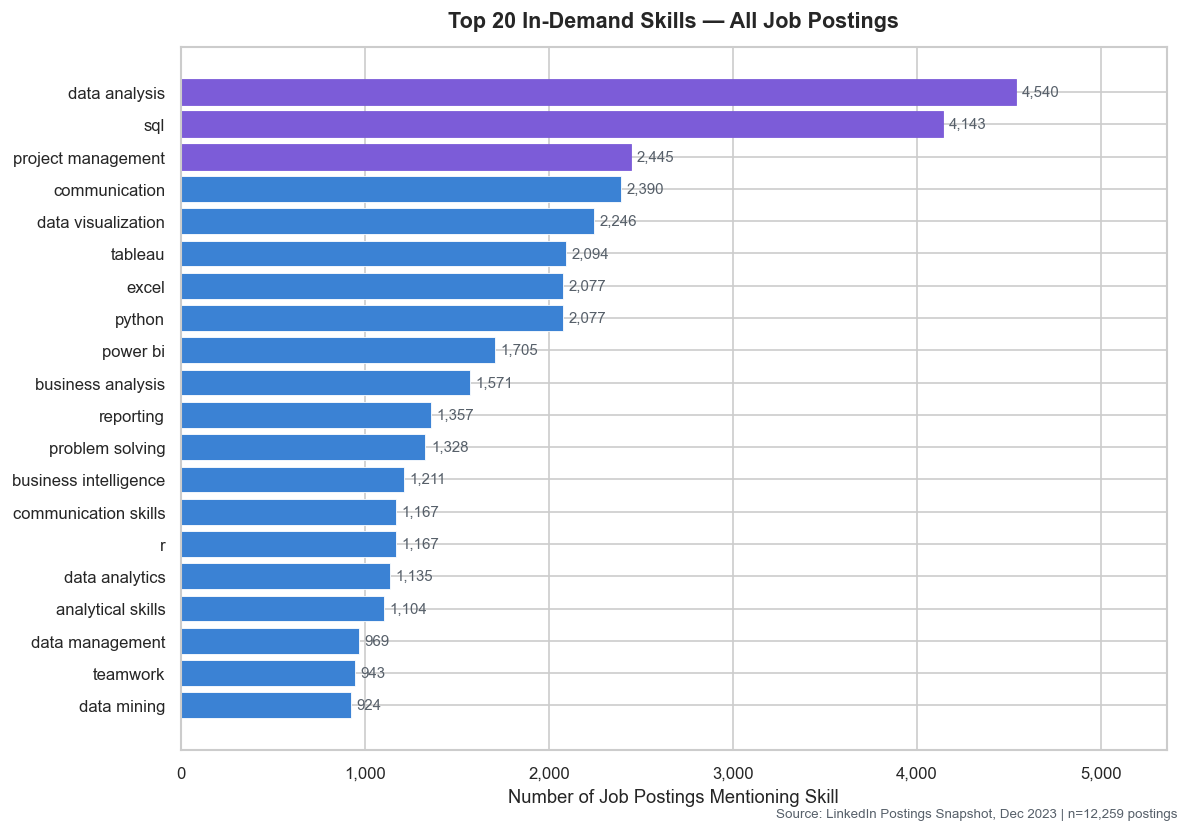

Chart 1 saved as chart1_top20_skills.png


In [18]:
# ── Chart 1: Top 20 Skills Overall ───────────────────────────────────────────
top20 = skill_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top20.index[::-1],
    top20.values[::-1],
    color=ACCENT,
    edgecolor='white',
    linewidth=0.5
)

# Highlight the top 3 bars
for bar in bars[-3:]:
    bar.set_color(SECONDARY)

# Value labels
for bar in bars:
    ax.text(
        bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', ha='left', fontsize=9, color=MUTED
    )

ax.set_title('Top 20 In-Demand Skills — All Job Postings', pad=12)
ax.set_xlabel('Number of Job Postings Mentioning Skill')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top20.max() * 1.18)

fig.text(
    0.99, 0.01,
    f'Source: LinkedIn Postings Snapshot, Dec 2023 | n={len(df_clean_skills):,} postings',
    ha='right', va='bottom', fontsize=8, color=MUTED
)
plt.tight_layout()
plt.savefig('chart1_top20_skills.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved as chart1_top20_skills.png')

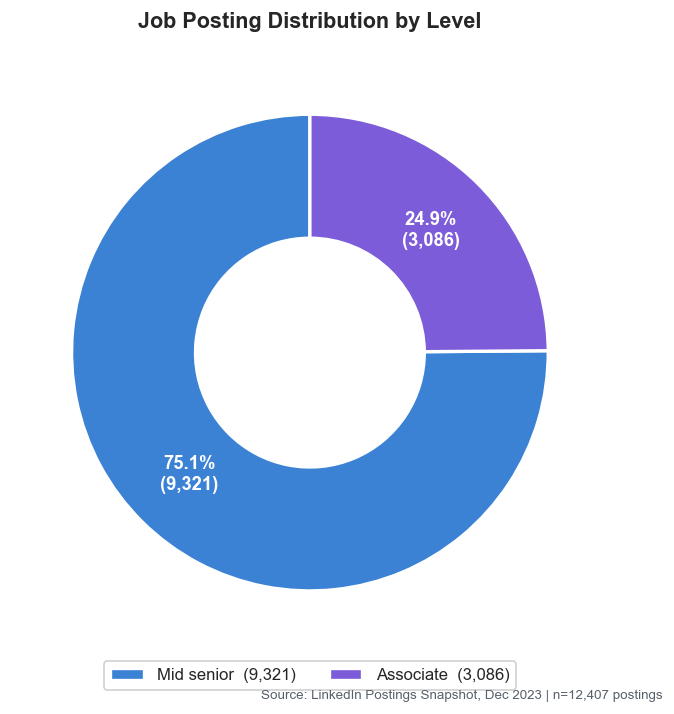

Chart 1b saved as chart1b_level_donut.png


In [19]:
# ── Chart 1b: Posting Split by Job Level — Donut Chart ────────────────────
level_counts = df['job_level'].value_counts()

labels = level_counts.index.tolist()
sizes  = level_counts.values.tolist()
total  = sum(sizes)
colors = [ACCENT, SECONDARY]

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total / 100)):,})',
    pctdistance=0.72,
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2),
)

# Style the percentage + count labels inside the wedges
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')
    at.set_fontweight('bold')

# Legend outside the donut
ax.legend(
    wedges, [f'{lbl}  ({cnt:,})' for lbl, cnt in zip(labels, sizes)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    framealpha=0.9,
    fontsize=10,
)

ax.set_title('Job Posting Distribution by Level', pad=16)

fig.text(
    0.99, 0.01,
    f'Source: LinkedIn Postings Snapshot, Dec 2023 | n={len(df):,} postings',
    ha='right', va='bottom', fontsize=8, color=MUTED
)
plt.tight_layout()
plt.savefig('chart1b_level_donut.png', bbox_inches='tight')
plt.show()
print('Chart 1b saved as chart1b_level_donut.png')


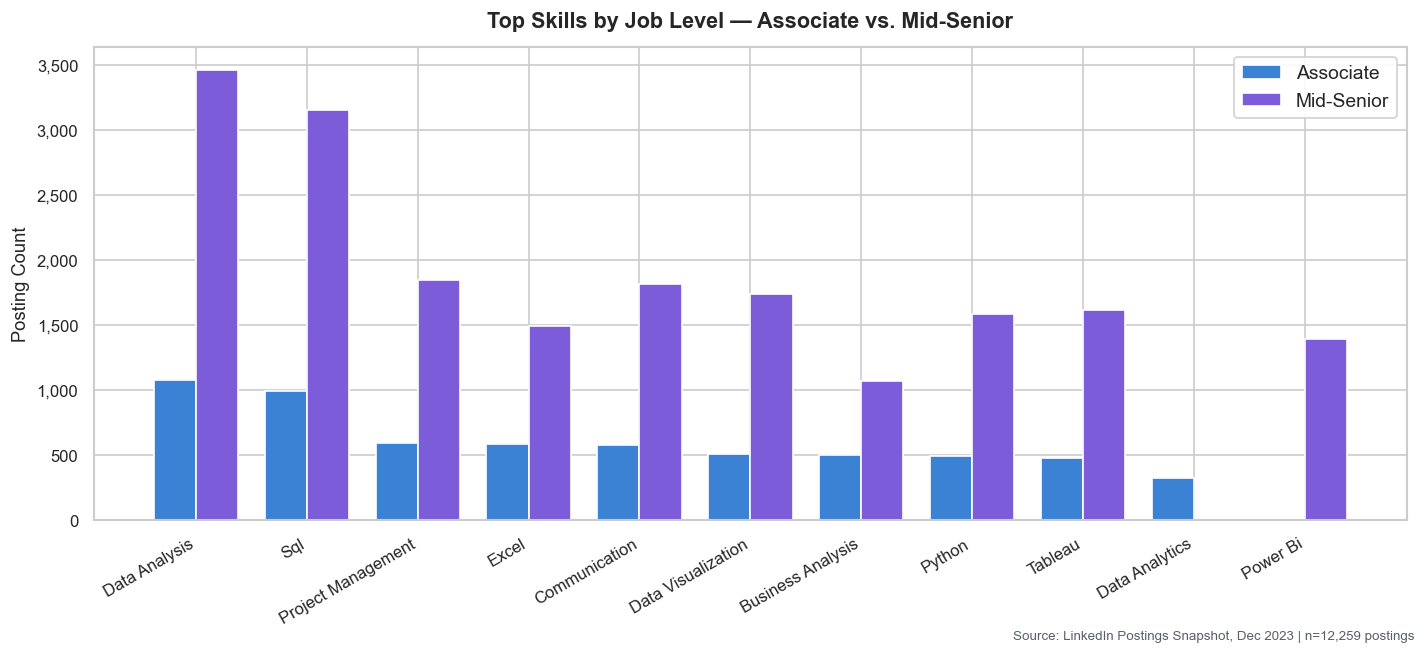

Chart 2 saved as chart2_skills_by_level.png


In [20]:
# ── Chart 2: Top 10 Skills — Associate vs. Mid-Senior ─────────────────────────
# Align on the union of top-10 skills from both levels
assoc_top10  = level_skill_data.get('Associate',   pd.Series()).head(10)
senior_top10 = level_skill_data.get('Mid senior',  pd.Series()).head(10)

all_level_skills = list(dict.fromkeys(
    list(assoc_top10.index) + list(senior_top10.index)
))[:12]  # cap at 12 for readability

assoc_vals  = [assoc_top10.get(s, 0)  for s in all_level_skills]
senior_vals = [senior_top10.get(s, 0) for s in all_level_skills]

x = np.arange(len(all_level_skills))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))
b1 = ax.bar(x - width/2, assoc_vals,  width, label='Associate',   color=ACCENT,     edgecolor='white')
b2 = ax.bar(x + width/2, senior_vals, width, label='Mid-Senior',  color=SECONDARY,  edgecolor='white')

ax.set_title('Top Skills by Job Level — Associate vs. Mid-Senior', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Posting Count')
ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in all_level_skills], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(framealpha=0.9)

fig.text(
    0.99, 0.01,
    f'Source: LinkedIn Postings Snapshot, Dec 2023 | n={len(df_clean_skills):,} postings',
    ha='right', va='bottom', fontsize=8, color=MUTED
)
plt.tight_layout()
plt.savefig('chart2_skills_by_level.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved as chart2_skills_by_level.png')

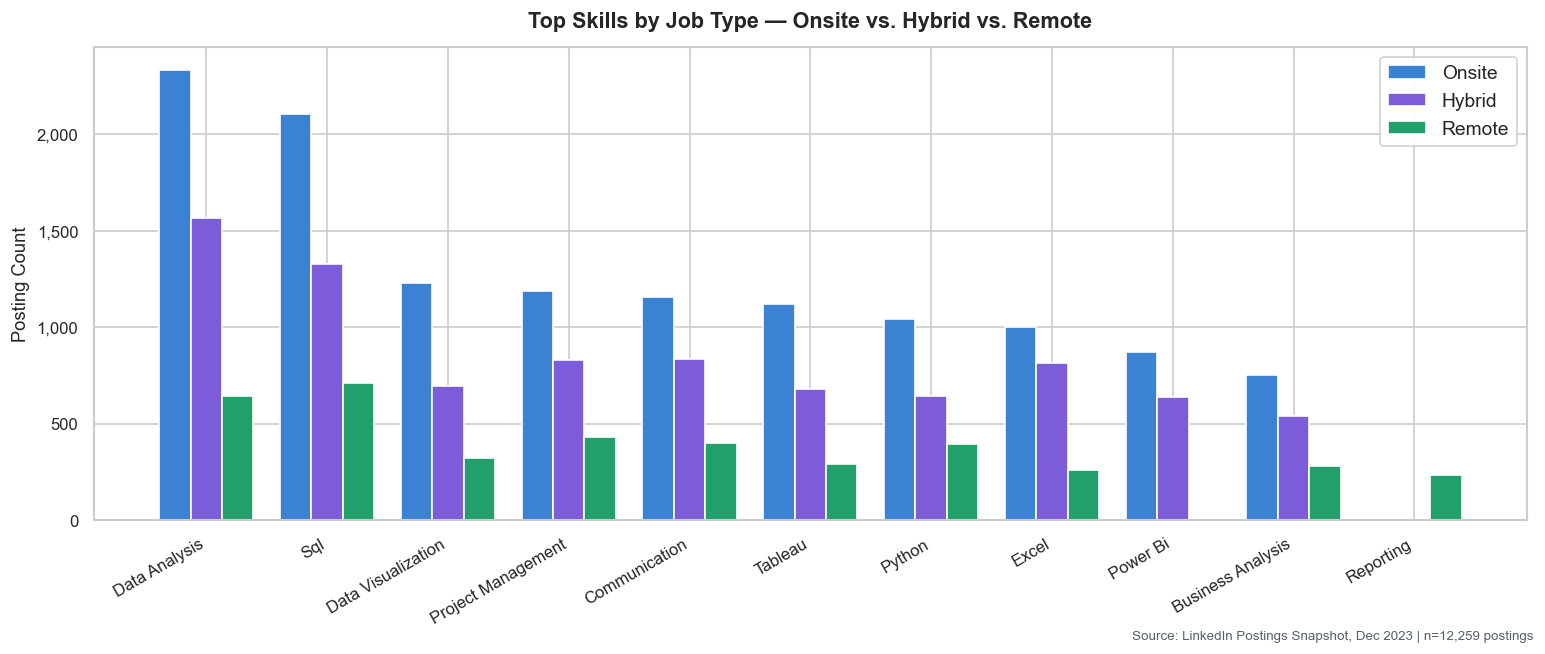

Chart 3 saved as chart3_skills_by_jobtype.png


In [21]:
# ── Chart 3: Top 10 Skills by Job Type (Onsite / Hybrid / Remote) ─────────────
onsite_top10 = type_skill_data.get('Onsite',  pd.Series()).head(10)
hybrid_top10 = type_skill_data.get('Hybrid',  pd.Series()).head(10)
remote_top10 = type_skill_data.get('Remote',  pd.Series()).head(10)

all_type_skills = list(dict.fromkeys(
    list(onsite_top10.index) + list(hybrid_top10.index) + list(remote_top10.index)
))[:12]

onsite_vals = [onsite_top10.get(s, 0) for s in all_type_skills]
hybrid_vals = [hybrid_top10.get(s, 0) for s in all_type_skills]
remote_vals = [remote_top10.get(s, 0) for s in all_type_skills]

x = np.arange(len(all_type_skills))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - width, onsite_vals, width, label='Onsite', color='#3b82d4', edgecolor='white')
ax.bar(x,         hybrid_vals, width, label='Hybrid', color='#7c5cd8', edgecolor='white')
ax.bar(x + width, remote_vals, width, label='Remote', color='#22a06b', edgecolor='white')

ax.set_title('Top Skills by Job Type — Onsite vs. Hybrid vs. Remote', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Posting Count')
ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in all_type_skills], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(framealpha=0.9)

fig.text(
    0.99, 0.01,
    f'Source: LinkedIn Postings Snapshot, Dec 2023 | n={len(df_clean_skills):,} postings',
    ha='right', va='bottom', fontsize=8, color=MUTED
)
plt.tight_layout()
plt.savefig('chart3_skills_by_jobtype.png', bbox_inches='tight')
plt.show()
print('Chart 3 saved as chart3_skills_by_jobtype.png')

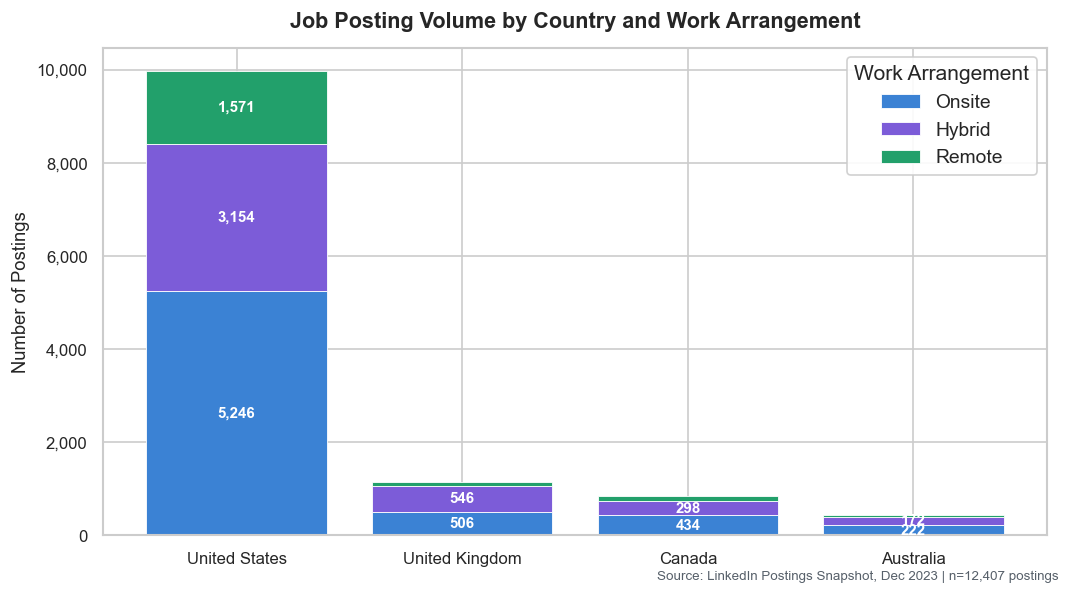

Chart 4 saved as chart4_volume_country_jobtype.png


In [22]:
# ── Chart 4: Posting Volume by Country × Job Type (stacked bar) ───────────────
# This replaces the unavailable time-trend chart. It shows the composition of
# the job market across four countries, broken down by work arrangement —
# a practical signal for job seekers deciding where (and how) to search.

volume_pivot = (
    df.groupby(['search_country', 'job_type'])
      .size()
      .unstack(fill_value=0)
      .reindex(['United States', 'United Kingdom', 'Canada', 'Australia'])
)

# Ensure all job type columns are present
for col in ['Onsite', 'Hybrid', 'Remote']:
    if col not in volume_pivot.columns:
        volume_pivot[col] = 0
volume_pivot = volume_pivot[['Onsite', 'Hybrid', 'Remote']]

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#3b82d4', '#7c5cd8', '#22a06b']
bottom = np.zeros(len(volume_pivot))

for col, color in zip(volume_pivot.columns, colors):
    vals = volume_pivot[col].values
    bars = ax.bar(volume_pivot.index, vals, bottom=bottom, label=col,
                  color=color, edgecolor='white', linewidth=0.5)
    # Label segments that are large enough
    for bar, v in zip(bars, vals):
        if v > 150:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{int(v):,}', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    bottom += vals

ax.set_title('Job Posting Volume by Country and Work Arrangement', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Postings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(title='Work Arrangement', framealpha=0.9)

fig.text(
    0.99, 0.01,
    f'Source: LinkedIn Postings Snapshot, Dec 2023 | n={len(df):,} postings',
    ha='right', va='bottom', fontsize=8, color=MUTED
)
plt.tight_layout()
plt.savefig('chart4_volume_country_jobtype.png', bbox_inches='tight')
plt.show()
print('Chart 4 saved as chart4_volume_country_jobtype.png')

In [23]:
# ── Summary & Key Takeaways — generated from live data ──────────────────
from IPython.display import display, Markdown

_ACRONYMS = {'Sql': 'SQL', 'Bi': 'BI', 'Gis': 'GIS', 'Erp': 'ERP'}
def _fix_caps(s):
    for wrong, right in _ACRONYMS.items():
        s = s.replace(wrong, right)
    return s

_s = skill_series
_r1 = f'{_fix_caps(_s.index[0].title())} ({int(_s.iloc[0]):,} postings)'
_r2 = f'{_fix_caps(_s.index[1].title())} ({int(_s.iloc[1]):,} postings)'
_top5 = ' · '.join(_fix_caps(s.title()) for s in _s.head(5).index)
_us_count = int(df[df['search_country'] == 'United States'].shape[0])
_assoc_cnt  = int(df[df['job_level'] == 'Associate'].shape[0])
_senior_cnt = int(df[df['job_level'] == 'Mid senior'].shape[0])

_table = (
    '---\n'
    '## Summary & Key Takeaways\n\n'
    '| Finding | Detail |\n'
    '|---------|--------|\n'
    + f'| **#1 skill overall** | {_r1} — essential at every level |\n'
    + f'| **#2 skill overall** | {_r2} |\n'
    + f'| **Core analyst stack** | {_top5} |\n'
    '| **Communication matters** | Ranks #3 overall — soft skills are explicitly listed requirements |\n'
    + f'| **Associate vs. Mid-Senior** | {_assoc_cnt:,} Associate vs {_senior_cnt:,} Mid-Senior postings; '
    'Associate roles emphasize Excel more; Mid-Senior skews toward Python and project management |\n'
    '| **Remote roles** | Slightly higher emphasis on Communication and Python vs. Onsite |\n'
    + f'| **Geography** | US dominates ({_us_count:,} postings); UK and Canada are sizeable markets |\n'
    '| **Dataset note** | Single-day snapshot (Dec 20, 2023); skills rankings are robust but no time trend is possible |\n'
    '\n---\n'
    '*Notebook: `Preethi_job_market_skill_analyzer.ipynb` — IBM Data Analytics with AI Internship Project*'
)

display(Markdown(_table))


---
## Summary & Key Takeaways

| Finding | Detail |
|---------|--------|
| **#1 skill overall** | Data Analysis (4,540 postings) — essential at every level |
| **#2 skill overall** | SQL (4,143 postings) |
| **Core analyst stack** | Data Analysis · SQL · Project Management · Communication · Data Visualization |
| **Communication matters** | Ranks #3 overall — soft skills are explicitly listed requirements |
| **Associate vs. Mid-Senior** | 3,086 Associate vs 9,321 Mid-Senior postings; Associate roles emphasize Excel more; Mid-Senior skews toward Python and project management |
| **Remote roles** | Slightly higher emphasis on Communication and Python vs. Onsite |
| **Geography** | US dominates (9,971 postings); UK and Canada are sizeable markets |
| **Dataset note** | Single-day snapshot (Dec 20, 2023); skills rankings are robust but no time trend is possible |

---
*Notebook: `Preethi_job_market_skill_analyzer.ipynb` — IBM Data Analytics with AI Internship Project*